# Coverage over time — Cultura vs Cross-Verified in 50-year bins, globally and by continent.

## Configuration

In [1]:
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from constants import CONTINENTS, LATIN_AMERICAN_COUNTRIES

CULTURA_DB_PATH        = '../data/humans_clean.duckdb'
CROSS_VERIFIED_DB_PATH = '../data/similar_databases/cross_verified.duckdb'

ADULT_ONSET_OFFSET = 30

BIN_SIZE       = 50
BIN_MIN        = -1500
BIN_MAX_START  = 1950

bins_50y = np.arange(BIN_MIN, BIN_MAX_START + 1, BIN_SIZE)

COLORS = {
    'cultura':        '#2f5b8a',
    'cross_verified': '#b5542a',
}

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})

## Connect

In [2]:
cultura_con        = duckdb.connect(CULTURA_DB_PATH,        read_only=True)
cross_verified_con = duckdb.connect(CROSS_VERIFIED_DB_PATH, read_only=True)

## Cultura — effective year per individual  (midpoint(birth, death) → birth+30 → death−30 → floruit_year → midpoint of floruit period)

In [3]:
cultura_individuals = cultura_con.execute("""
    SELECT  wikidata_id,
            COALESCE(
                CASE WHEN birth_year IS NOT NULL AND death_year IS NOT NULL
                     THEN CAST((birth_year + death_year) / 2 AS BIGINT) END,
                CASE WHEN birth_year IS NOT NULL THEN birth_year + 30 END,
                CASE WHEN death_year IS NOT NULL THEN death_year - 30 END,
                floruit_year,
                CASE WHEN floruit_period_start IS NOT NULL AND floruit_period_end IS NOT NULL
                     THEN CAST((floruit_period_start + floruit_period_end) / 2 AS BIGINT) END,
                floruit_period_start,
                floruit_period_end
            ) AS floruit_year
    FROM    individuals_floruit_period
""").pl()

n_with_year = cultura_individuals.filter(pl.col('floruit_year').is_not_null()).height
print('shape:', cultura_individuals.shape)
print(f'with at least one date: {n_with_year:,}  ({n_with_year / cultura_individuals.height:.1%})')
cultura_individuals.head()

shape: (13003420, 2)
with at least one date: 10,092,643  (77.6%)


wikidata_id,floruit_year
str,i64
"""Q101553124""",2020
"""Q101553254""",null
"""Q101553398""",2005
"""Q101553548""",1977
"""Q101553561""",null


## Cross-Verified — floruit year per individual  (midpoint of birth/death; else ±30 from the known one)

In [4]:
cross_verified = cross_verified_con.execute(f"""
    SELECT  wikidata_code,
            CASE
                WHEN birth IS NOT NULL AND COALESCE(death, updated_death_date) IS NOT NULL
                    THEN CAST((birth + COALESCE(death, updated_death_date)) / 2 AS BIGINT)
                WHEN birth IS NOT NULL
                    THEN birth + {ADULT_ONSET_OFFSET}
                WHEN COALESCE(death, updated_death_date) IS NOT NULL
                    THEN COALESCE(death, updated_death_date) - {ADULT_ONSET_OFFSET}
            END AS floruit_year
    FROM    individuals
""").pl()

print('shape:', cross_verified.shape)
cross_verified.head()

shape: (2291817, 2)


wikidata_code,floruit_year
str,i64
"""Q1000002""",1961
"""Q1000005""",1894
"""Q1000006""",2001
"""Q1000015""",2013
"""Q1000023""",1944


## Per-bin counts  (Cultura vs Cross-Verified, 50-year buckets)

In [5]:
def per_bin_50y(df, year_column):
    counts = (
        df.filter(pl.col(year_column).is_not_null())
          .with_columns(((pl.col(year_column) // BIN_SIZE) * BIN_SIZE).cast(pl.Int64).alias('bin'))
          .filter((pl.col('bin') >= BIN_MIN) & (pl.col('bin') <= BIN_MAX_START))
          .group_by('bin').len().rename({'len': 'n'})
    )
    lookup = dict(counts.iter_rows())
    return np.array([lookup.get(int(b), 0) for b in bins_50y])

cultura_per_bin        = per_bin_50y(cultura_individuals, 'floruit_year')
cross_verified_per_bin = per_bin_50y(cross_verified,      'floruit_year')

per_bin_global = pl.DataFrame({
    'bin':            bins_50y.tolist(),
    'cultura':        cultura_per_bin.tolist(),
    'cross_verified': cross_verified_per_bin.tolist(),
})

print('shape:', per_bin_global.shape)
per_bin_global.head()

shape: (70, 3)


bin,cultura,cross_verified
i64,i64,i64
-1500,100,10
-1450,83,6
-1400,100,17
-1350,97,23
-1300,79,18


### Fig 1 — Global evolution, two panels  (pre-1500 CE, then 1500–1900 CE)

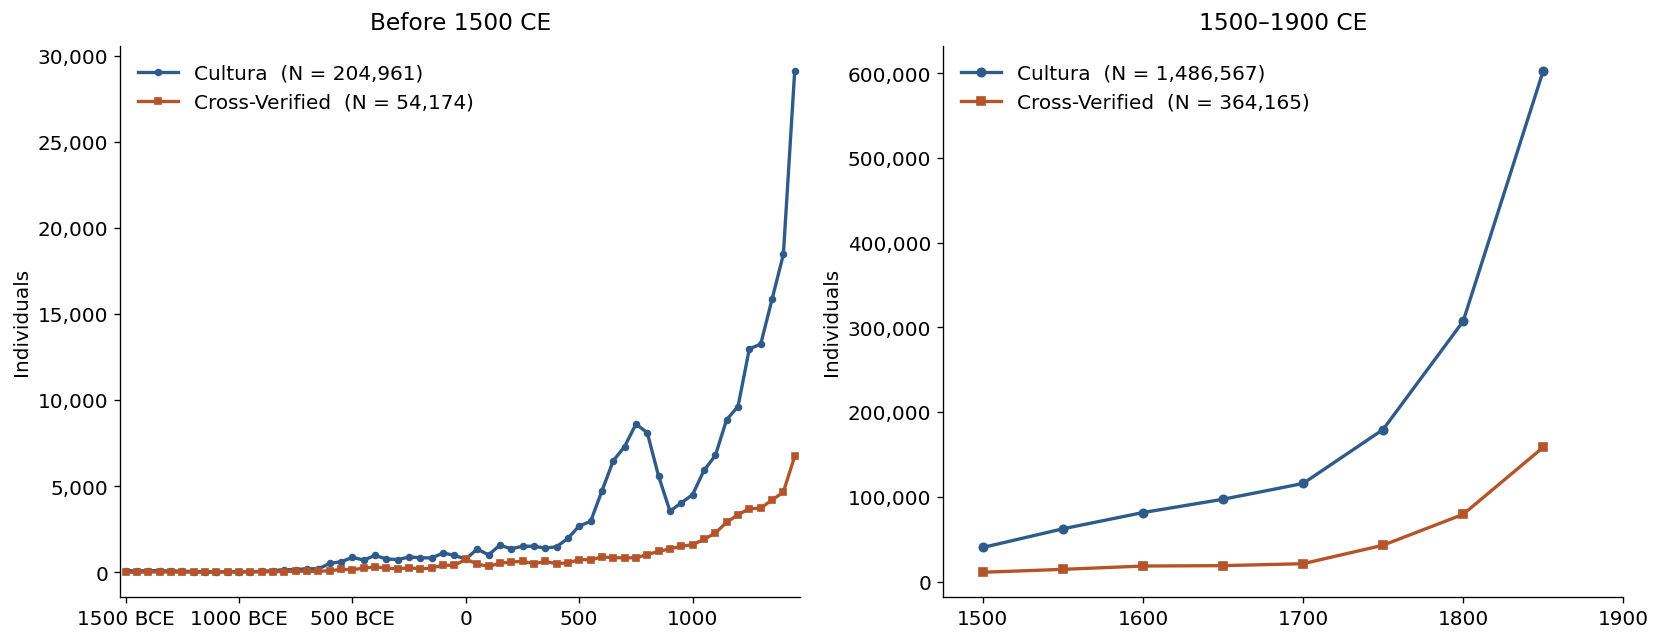

In [6]:
PRE_MODERN_BREAK = 1500
MODERN_END       = 1900

def format_year_label(year):
    if year < 0:
        return f'{abs(year)} BCE'
    return f'{year}'

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5.5))

premodern_mask = bins_50y < PRE_MODERN_BREAK
ax_left.plot(bins_50y[premodern_mask], cultura_per_bin[premodern_mask],
             color=COLORS['cultura'], lw=2.0, marker='o', ms=3.5,
             label=f"Cultura  (N = {int(cultura_per_bin[premodern_mask].sum()):,})")
ax_left.plot(bins_50y[premodern_mask], cross_verified_per_bin[premodern_mask],
             color=COLORS['cross_verified'], lw=2.0, marker='s', ms=3.5,
             label=f"Cross-Verified  (N = {int(cross_verified_per_bin[premodern_mask].sum()):,})")
ax_left.set_xlim(BIN_MIN - 25, PRE_MODERN_BREAK - 25)
premodern_ticks = np.arange(-1500, PRE_MODERN_BREAK, 500)
ax_left.set_xticks(premodern_ticks)
ax_left.set_xticklabels([format_year_label(int(t)) for t in premodern_ticks])
ax_left.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))
ax_left.set_title('Before 1500 CE', fontsize=14, color='black', pad=10)
ax_left.set_ylabel('Individuals')
ax_left.legend(loc='upper left', frameon=False)

modern_mask = (bins_50y >= PRE_MODERN_BREAK) & (bins_50y < MODERN_END)
ax_right.plot(bins_50y[modern_mask], cultura_per_bin[modern_mask],
              color=COLORS['cultura'], lw=2.0, marker='o', ms=5,
              label=f"Cultura  (N = {int(cultura_per_bin[modern_mask].sum()):,})")
ax_right.plot(bins_50y[modern_mask], cross_verified_per_bin[modern_mask],
              color=COLORS['cross_verified'], lw=2.0, marker='s', ms=5,
              label=f"Cross-Verified  (N = {int(cross_verified_per_bin[modern_mask].sum()):,})")
ax_right.set_xlim(PRE_MODERN_BREAK - 25, MODERN_END - 25)
modern_ticks = np.arange(PRE_MODERN_BREAK, MODERN_END + 1, 100)
ax_right.set_xticks(modern_ticks)
ax_right.set_xticklabels([str(int(t)) for t in modern_ticks])
ax_right.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y):,}'))
ax_right.set_title('1500–1900 CE', fontsize=14, color='black', pad=10)
ax_right.set_ylabel('Individuals')
ax_right.legend(loc='upper left', frameon=False)

fig.tight_layout()
plt.show()

## Country → continent mapping  (with Latin-America override)

In [7]:
def regroup_continent(country, native_continent):
    if country in LATIN_AMERICAN_COUNTRIES:
        return 'Latin America'
    if native_continent in {'North America', 'South America'}:
        return 'North America'
    if native_continent in {'Europe', 'Asia', 'Africa', 'Oceania'}:
        return native_continent
    return None

country_continent_raw = cultura_con.execute("""
    SELECT DISTINCT country_name, continent
    FROM   polities_modern_countries_cliopatria
    WHERE  country_name IS NOT NULL AND continent IS NOT NULL
""").pl()

country_to_continent = {
    row['country_name']: regrouped
    for row in country_continent_raw.iter_rows(named=True)
    if (regrouped := regroup_continent(row['country_name'], row['continent'])) is not None
}

country_continent_lookup = pl.DataFrame({
    'country_name': list(country_to_continent.keys()),
    'continent':    list(country_to_continent.values()),
})

print(f'countries mapped: {len(country_to_continent):,}')
country_continent_lookup.head()

countries mapped: 192


country_name,continent
str,str
"""Sri Lanka""","""Asia"""
"""Yemen""","""Asia"""
"""Pakistan""","""Asia"""
"""Armenia""","""Asia"""
"""Myanmar""","""Asia"""


## Cultura individual ↔ continent  (via polity → modern country, OR via `individuals.country_of_citizenship_en`)

In [8]:
cultura_individual_country = cultura_con.execute("""
    WITH country_via_polity AS (
        SELECT DISTINCT
               cliopatria.wikidata_id,
               modern_country.country_name
        FROM       individuals_cliopatria               AS cliopatria
        JOIN       polities_modern_countries_cliopatria AS modern_country
                   ON cliopatria.polity_name = modern_country.polity_name
        WHERE      modern_country.country_name IS NOT NULL
    ),
    country_via_citizenship AS (
        SELECT  wikidata_id,
                TRIM(country_token) AS country_name
        FROM (
            SELECT  wikidata_id,
                    UNNEST(string_split(country_of_citizenship_en, ';')) AS country_token
            FROM    individuals
            WHERE   country_of_citizenship_en IS NOT NULL
              AND   country_of_citizenship_en != ''
        )
        WHERE   TRIM(country_token) != ''
    )
    SELECT DISTINCT wikidata_id, country_name FROM country_via_polity
    UNION
    SELECT DISTINCT wikidata_id, country_name FROM country_via_citizenship
""").pl()

cultura_individual_continent = (
    cultura_individual_country
    .join(country_continent_lookup, on='country_name', how='inner')
    .join(cultura_individuals, on='wikidata_id', how='inner')
    .filter(pl.col('floruit_year').is_not_null())
    .select('wikidata_id', 'continent', 'floruit_year')
    .unique()
)

print('shape:', cultura_individual_continent.shape)
cultura_individual_continent.head()

shape: (5759963, 3)


wikidata_id,continent,floruit_year
str,str,i64
"""Q106327753""","""Europe""",1984
"""Q27831998""","""Europe""",2007
"""Q16008357""","""Europe""",1940
"""Q79296""","""Europe""",1972
"""Q4082869""","""Asia""",1950


## Cross-Verified individual ↔ continent  (via citizenship_1_b ∪ citizenship_2_b)

In [9]:
CV_CITIZENSHIP_TO_COUNTRY_ALIAS = {
    'US':                                 'United States',
    'United_States':                      'United States',
    'UK':                                 'United Kingdom',
    'Great_Britain':                      'United Kingdom',
    'South_Korea':                        'South Korea',
    'North_Korea':                        'North Korea',
    'East_Timor':                         'Timor-Leste',
    'Czechoslovakia':                     'Czech Republic',
    'Yugoslavia':                         'Serbia',
    'Macedonia':                          'North Macedonia',
    'The_Bahamas':                        'The Bahamas',
    'Vatican':                            'Vatican City',
    'Hong_Kong':                          'China',
    'Burma':                              'Myanmar',
    'Ivory_Coast':                        "Cote d'Ivoire",
    'Congo_Republic':                     'Republic of the Congo',
    'Democratic_Republic_of_the_Congo':   'Democratic Republic of the Congo',
}

def cv_citizenship_to_continent(cv_citizenship):
    if cv_citizenship is None:
        return None
    candidate_country = CV_CITIZENSHIP_TO_COUNTRY_ALIAS.get(cv_citizenship, cv_citizenship.replace('_', ' '))
    return country_to_continent.get(candidate_country)

cv_citizenship_rows = cross_verified_con.execute(f"""
    SELECT  wikidata_code,
            citizenship_1_b,
            citizenship_2_b,
            CASE
                WHEN birth IS NOT NULL AND COALESCE(death, updated_death_date) IS NOT NULL
                    THEN CAST((birth + COALESCE(death, updated_death_date)) / 2 AS BIGINT)
                WHEN birth IS NOT NULL
                    THEN birth + {ADULT_ONSET_OFFSET}
                WHEN COALESCE(death, updated_death_date) IS NOT NULL
                    THEN COALESCE(death, updated_death_date) - {ADULT_ONSET_OFFSET}
            END AS floruit_year
    FROM individuals
""").pl()

cv_individual_continent = (
    cv_citizenship_rows
    .with_columns(
        pl.col('citizenship_1_b').map_elements(cv_citizenship_to_continent, return_dtype=pl.Utf8).alias('continent_1'),
        pl.col('citizenship_2_b').map_elements(cv_citizenship_to_continent, return_dtype=pl.Utf8).alias('continent_2'),
    )
    .with_columns(pl.concat_list(['continent_1', 'continent_2']).alias('continents'))
    .select('wikidata_code', 'floruit_year', 'continents')
    .explode('continents')
    .filter(pl.col('continents').is_not_null())
    .rename({'continents': 'continent'})
    .unique(subset=['wikidata_code', 'continent', 'floruit_year'])
)

print('shape:', cv_individual_continent.shape)
cv_individual_continent.head()

shape: (2218996, 3)


wikidata_code,floruit_year,continent
str,i64,str
"""Q5233540""",1958,"""Europe"""
"""Q5560778""",1752,"""Europe"""
"""Q695002""",1934,"""Europe"""
"""Q7366701""",1858,"""Oceania"""
"""Q4725232""",1985,"""Latin America"""


### Augment Cultura with CV's continent assignment for overlap individuals  (so CV ⊂ Cultura per (continent, bin))

In [10]:
cultura_qid_set = set(cultura_individuals['wikidata_id'].to_list())

cv_overlap_continent_for_cultura = (
    cv_individual_continent
    .filter(pl.col('wikidata_code').is_in(cultura_qid_set))
    .select('wikidata_code', 'continent', 'floruit_year')
    .rename({'wikidata_code': 'wikidata_id'})
    .unique()
)

cultura_individual_continent = pl.concat([
    cultura_individual_continent,
    cv_overlap_continent_for_cultura,
]).unique(subset=['wikidata_id', 'continent', 'floruit_year'])

print('shape:', cultura_individual_continent.shape)
cultura_individual_continent.head()

shape: (6157536, 3)


wikidata_id,continent,floruit_year
str,str,i64
"""Q135363380""","""Latin America""",2033
"""Q18631545""","""North America""",1973
"""Q104650169""","""North America""",2015
"""Q16627137""","""Europe""",1928
"""Q21932164""","""North America""",null


## Per-bin counts per continent

In [11]:
def per_bin_for_continent(df, continent):
    return per_bin_50y(df.filter(pl.col('continent') == continent), 'floruit_year')

continent_series = {
    continent: {
        'cultura':        per_bin_for_continent(cultura_individual_continent, continent),
        'cross_verified': per_bin_for_continent(cv_individual_continent,      continent),
    }
    for continent in CONTINENTS
}

continent_summary = pl.DataFrame([
    {
        'continent':      continent,
        'cultura':        int(series['cultura'].sum()),
        'cross_verified': int(series['cross_verified'].sum()),
    }
    for continent, series in continent_series.items()
])

print('shape:', continent_summary.shape)
continent_summary

shape: (6, 3)


continent,cultura,cross_verified
str,i64,i64
"""Europe""",2739241,960779
"""Asia""",776435,104979
"""Africa""",73081,30404
"""North America""",629752,345176
"""Latin America""",187545,94886
"""Oceania""",80233,53629


### Fig 2 — Cultura vs Cross-Verified per 50-year bin, faceted by continent  (log scale)

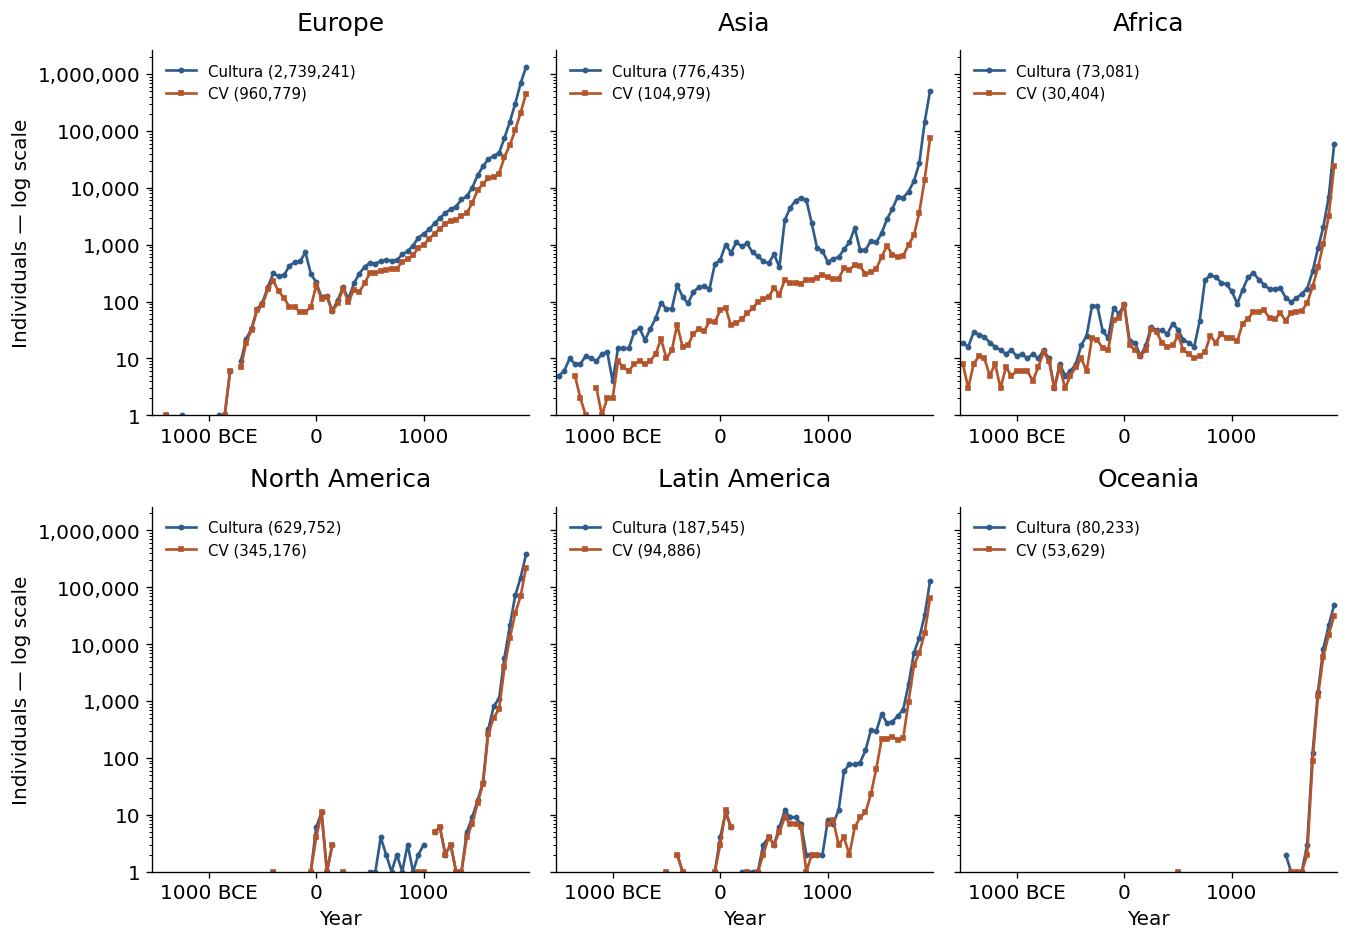

In [12]:
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.8 * n_cols, 4.0 * n_rows), sharey=True)

y_top = max(
    max(int(s['cultura'].max() or 0), int(s['cross_verified'].max() or 0))
    for s in continent_series.values()
) * 2

tick_step = 1000
ticks = np.array([t for t in range(-2000, 2001, tick_step) if BIN_MIN <= t <= BIN_MAX_START])

for ax, continent in zip(axes.flat, CONTINENTS):
    cultura_continent_series        = continent_series[continent]['cultura']
    cross_verified_continent_series = continent_series[continent]['cross_verified']

    ax.plot(bins_50y, np.where(cultura_continent_series > 0, cultura_continent_series, np.nan),
            color=COLORS['cultura'], lw=1.6, marker='o', ms=2.5,
            label=f'Cultura ({int(cultura_continent_series.sum()):,})')
    ax.plot(bins_50y, np.where(cross_verified_continent_series > 0, cross_verified_continent_series, np.nan),
            color=COLORS['cross_verified'], lw=1.6, marker='s', ms=2.5,
            label=f'CV ({int(cross_verified_continent_series.sum()):,})')

    ax.set_yscale('log')
    ax.set_ylim(1, y_top)
    ax.set_xlim(BIN_MIN - 25, BIN_MAX_START + BIN_SIZE - 25)
    ax.set_xticks(ticks)
    ax.set_xticklabels([format_year_label(int(t)) for t in ticks], rotation=0)
    ax.set_title(continent, fontsize=15, color='black', pad=12)
    ax.legend(loc='upper left', frameon=False, fontsize=9)

for ax in axes[-1, :]:
    ax.set_xlabel('Year')
for ax in axes[:, 0]:
    ax.set_ylabel('Individuals — log scale')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}' if x >= 1 else ''))

fig.tight_layout()
plt.show()

## Close connections

In [13]:
cultura_con.close()
cross_verified_con.close()